# Analysis — What Do the Top 10% Most Popular Spotify Songs Have in Common?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/spotify_cleaned.csv")
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(49999, 23)


In [2]:
# Define top 10% popularity threshold (Dhruv T Upadhyay)
threshold = df['popularity'].quantile(0.90)
print(f"Top 10% popularity threshold: {threshold}")

# Split into top 10% and the rest
top10 = df[df['popularity'] >= threshold]
rest  = df[df['popularity'] < threshold]

print(f"Top 10% songs: {len(top10)}")
print(f"Rest of songs: {len(rest)}")

Top 10% popularity threshold: 62.0
Top 10% songs: 5453
Rest of songs: 44546


In [3]:
# Compare average audio features between top 10% and the rest
features = ['danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'valence', 
            'tempo', 'instrumentalness']

comparison = pd.DataFrame({
    'top_10_percent': top10[features].mean(),
    'rest':           rest[features].mean()
})

comparison['difference'] = comparison['top_10_percent'] - comparison['rest']
print(comparison.round(3))

                  top_10_percent     rest  difference
danceability               0.597    0.562       0.034
energy                     0.657    0.640       0.017
loudness                  -7.261   -8.367       1.107
speechiness                0.077    0.085      -0.008
acousticness               0.254    0.321      -0.066
valence                    0.486    0.472       0.014
tempo                    120.733  122.392      -1.660
instrumentalness           0.063    0.167      -0.104


In [4]:
# What percentage of top 10% songs are explicit?
top10_explicit = top10['explicit'].mean() * 100
rest_explicit  = rest['explicit'].mean() * 100

print(f"Explicit in top 10%: {top10_explicit:.1f}%")
print(f"Explicit in rest:    {rest_explicit:.1f}%")

Explicit in top 10%: 13.4%
Explicit in rest:    7.8%


In [5]:
# Which genres dominate the top 10%?
top_genres = top10['track_genre'].value_counts().head(10)
print("Top 10 genres in the top 10% most popular songs:")
print(top_genres)

Top 10 genres in the top 10% most popular songs:
track_genre
pop          280
k-pop        204
metal        197
electro      181
house        177
pop-film     165
edm          165
hard-rock    146
indie-pop    145
grunge       125
Name: count, dtype: int64


In [6]:
# What tempo category do top 10% songs fall into?
print("Tempo category distribution in top 10%:")
print(top10['tempo_category'].value_counts())
print()
print("Tempo category distribution in rest:")
print(rest['tempo_category'].value_counts())

Tempo category distribution in top 10%:
tempo_category
medium    2944
fast      1784
slow       725
Name: count, dtype: int64

Tempo category distribution in rest:
tempo_category
medium    21537
fast      16534
slow       6475
Name: count, dtype: int64


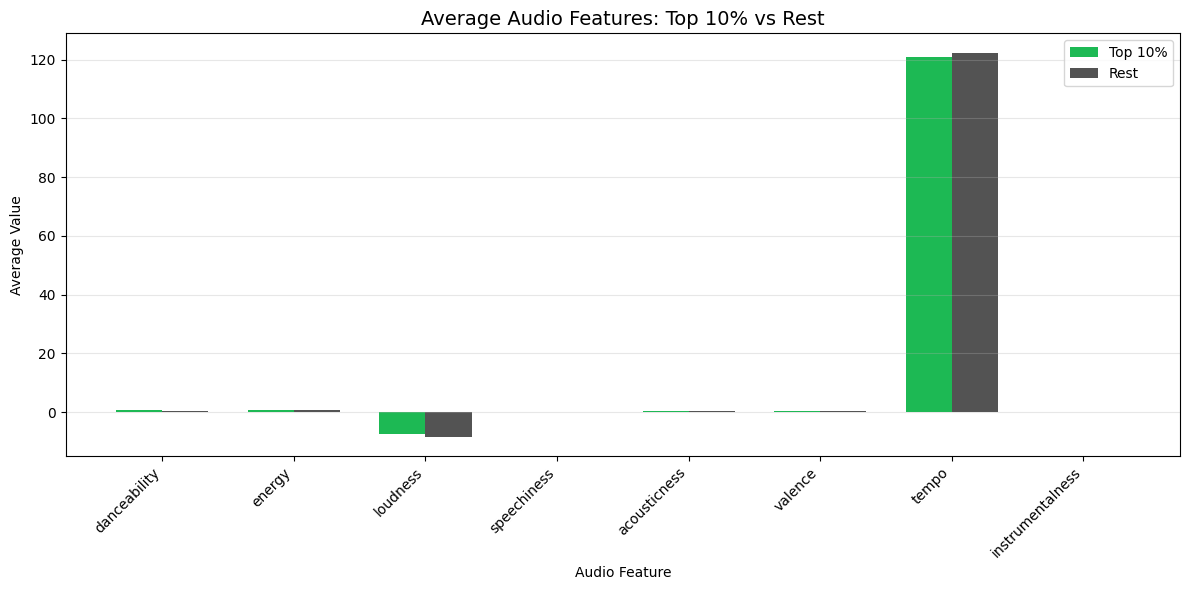

Figure saved!


In [7]:
# Bar chart — average audio features comparison
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(features))
width = 0.35

bars1 = ax.bar(x - width/2, comparison['top_10_percent'], 
               width, label='Top 10%', color='#1DB954')
bars2 = ax.bar(x + width/2, comparison['rest'], 
               width, label='Rest', color='#535353')

ax.set_title('Average Audio Features: Top 10% vs Rest', fontsize=14)
ax.set_xlabel('Audio Feature')
ax.set_ylabel('Average Value')
ax.set_xticks(x)
ax.set_xticklabels(features, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_vs_rest_features.png", dpi=300)
plt.show()
print("Figure saved!")

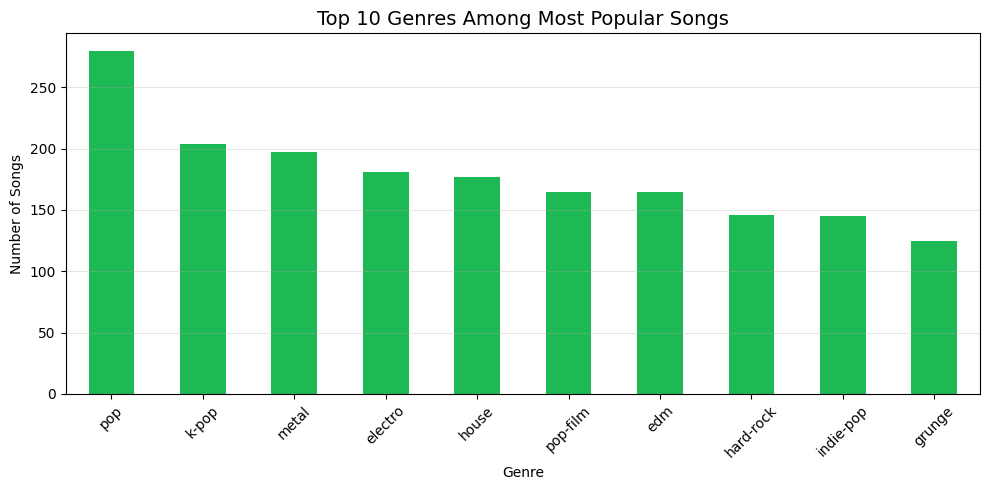

Figure saved!


In [8]:
# Bar chart — top genres in top 10%
fig, ax = plt.subplots(figsize=(10, 5))

top_genres.plot(kind='bar', ax=ax, color='#1DB954')

ax.set_title('Top 10 Genres Among Most Popular Songs', fontsize=14)
ax.set_xlabel('Genre')
ax.set_ylabel('Number of Songs')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_genres.png", dpi=300)
plt.show()
print("Figure saved!")

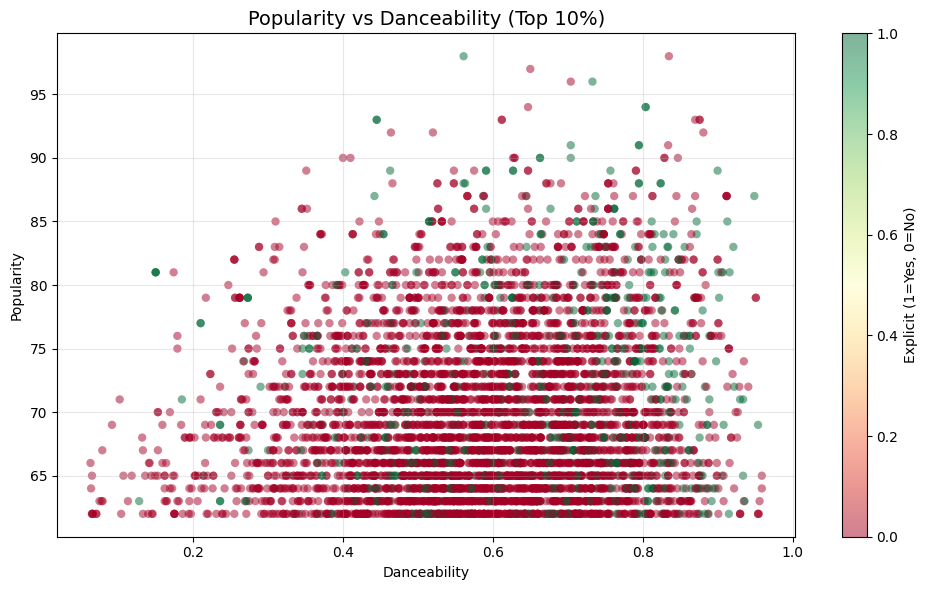

Figure saved!


In [9]:
# Scatter plot — popularity vs danceability colored by explicit
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    top10['danceability'],
    top10['popularity'],
    c=top10['explicit'],
    cmap='RdYlGn',
    alpha=0.5,
    edgecolors='none'
)

ax.set_title('Popularity vs Danceability (Top 10%)', fontsize=14)
ax.set_xlabel('Danceability')
ax.set_ylabel('Popularity')
plt.colorbar(scatter, label='Explicit (1=Yes, 0=No)')
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/top10_popularity_danceability.png", dpi=300)
plt.show()
print("Figure saved!")

## Key Findings — What Do Top 10% Most Popular Spotify Songs Have in Common?

### Audio Features
- Top 10% songs have **higher danceability** than the rest
- Top 10% songs tend to be **less instrumental** — more vocal/lyric driven
- Top 10% songs are slightly **louder** on average
- **Valence (happiness)** is slightly higher in popular songs

### Explicit Content
- **13.4%** of top 10% songs are explicit
- vs **7.8%** in the rest of songs
- Explicit songs are **almost twice as likely** to appear in the top 10%
- This suggests explicit content does correlate with higher popularity

### Genres
- The most popular genres are **pop, k-pop, and metal**
- Pop dominates with 280 songs, followed by k-pop (204) and metal (197)
- EDM, house, and electro also appear strongly — energy-driven genres perform well
- Indie-pop and grunge also make the top 10 — diverse taste in popular music

### Tempo
- Most popular songs fall in the **medium tempo** range (90-130 BPM)
- **54%** of top 10% songs are medium tempo
- Only **13%** are slow tempo — slow songs rarely hit the top

### Conclusion
The "formula" for a popular Spotify song appears to be:
- ✅ High danceability
- ✅ Moderate to high energy
- ✅ Low instrumentalness — vocal/lyric driven songs do better
- ✅ Medium tempo (90-130 BPM)
- ✅ Belongs to **pop, k-pop, metal, or EDM** genres
- ✅ Slightly more likely to be explicit

## Question 2 — Do Happy Songs Get More Popular or Do People Prefer Sad Songs?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("../data/processed/spotify_cleaned.csv")
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(49999, 23)


In [2]:
# Define happy, neutral and sad songs based on valence (Dhruv T Upadhyay)
def mood_category(valence):
    if valence >= 0.7:
        return 'Happy'
    elif valence <= 0.3:
        return 'Sad'
    else:
        return 'Neutral'

df['mood'] = df['valence'].apply(mood_category)

print("Mood distribution:")
print(df['mood'].value_counts())

Mood distribution:
mood
Neutral    23521
Sad        14903
Happy      11575
Name: count, dtype: int64


In [3]:
# Average popularity by mood
mood_popularity = df.groupby('mood')['popularity'].agg(['mean', 'count', 'std'])
print("Average popularity by mood:")
print(mood_popularity.round(3))

Average popularity by mood:
           mean  count     std
mood                          
Happy    30.928  11575  22.207
Neutral  34.208  23521  22.871
Sad      33.567  14903  21.253


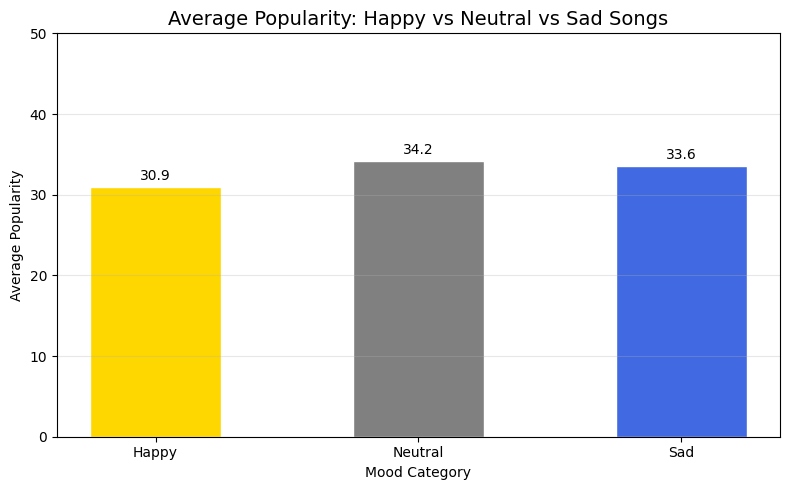

Figure saved!


In [4]:
# Bar plot — popularity by mood
fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Happy': '#FFD700', 'Neutral': '#808080', 'Sad': '#4169E1'}
moods = mood_popularity.index.tolist()
values = mood_popularity['mean'].values

bars = ax.bar(moods,
              values,
              color=[colors[m] for m in moods],
              edgecolor='white',
              width=0.5)

ax.set_title('Average Popularity: Happy vs Neutral vs Sad Songs', fontsize=14)
ax.set_xlabel('Mood Category')
ax.set_ylabel('Average Popularity')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 50)

fig.tight_layout()
fig.savefig("../figures/popularity_by_mood.png", dpi=300)
plt.show()
print("Figure saved!")

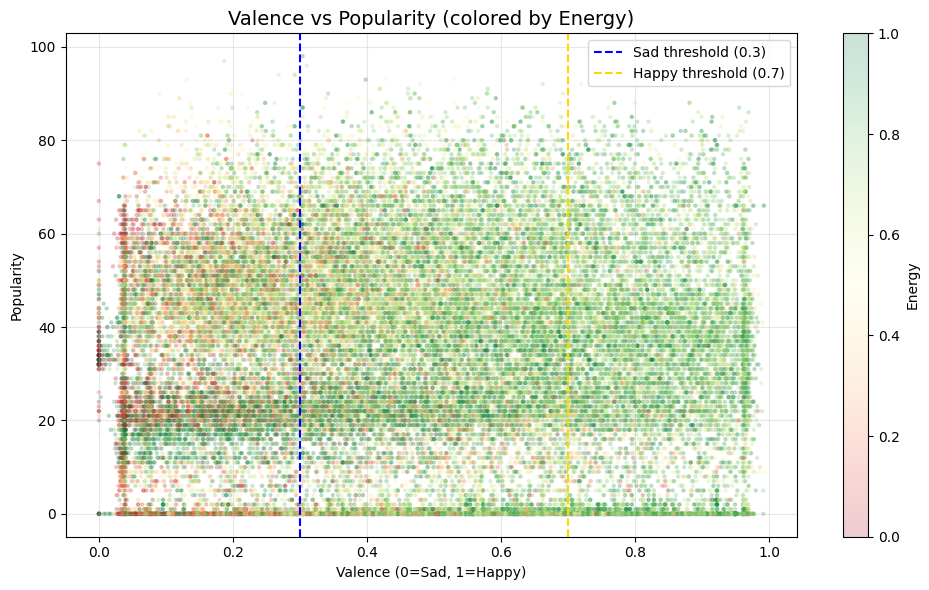

Figure saved!


In [5]:
# Scatter plot — valence vs popularity
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df['valence'],
    df['popularity'],
    c=df['energy'],
    cmap='RdYlGn',
    alpha=0.2,
    s=5
)

plt.colorbar(scatter, label='Energy')
ax.set_title('Valence vs Popularity (colored by Energy)', fontsize=14)
ax.set_xlabel('Valence (0=Sad, 1=Happy)')
ax.set_ylabel('Popularity')
ax.axvline(0.3, color='blue', linestyle='--', 
           linewidth=1.5, label='Sad threshold (0.3)')
ax.axvline(0.7, color='gold', linestyle='--', 
           linewidth=1.5, label='Happy threshold (0.7)')
ax.legend()
ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/valence_vs_popularity.png", dpi=300)
plt.show()
print("Figure saved!")

In [6]:
# Which genres are the happiest vs saddest?
genre_valence = df.groupby('track_genre')['valence'].mean().sort_values(ascending=False)

print("Top 5 happiest genres:")
print(genre_valence.head(5).round(3))
print()
print("Top 5 saddest genres:")
print(genre_valence.tail(5).round(3))

Top 5 happiest genres:
track_genre
salsa         0.810
forro         0.765
rockabilly    0.717
afrobeat      0.707
children      0.693
Name: valence, dtype: float64

Top 5 saddest genres:
track_genre
black-metal    0.196
new-age        0.179
ambient        0.169
iranian        0.159
sleep          0.057
Name: valence, dtype: float64


In [7]:
# Are sad songs more popular in specific genres?
mood_genre = df.groupby(['track_genre', 'mood'])['popularity'].mean().unstack(fill_value=0)
print("Popularity by mood per genre (first 10 genres):")
print(mood_genre.head(10).round(2))

Popularity by mood per genre (first 10 genres):
mood         Happy  Neutral    Sad
track_genre                       
acoustic     38.41    43.05  44.29
afrobeat     23.22    26.04  25.67
alt-rock     28.02    32.07  33.72
alternative  14.32    26.20  30.32
ambient      39.40    42.64  44.89
anime        48.74    49.59  47.16
black-metal  23.00    22.37  22.97
bluegrass    24.32    26.54  26.75
blues        25.06    35.31  33.72
brazil       43.70    45.54  46.37


In [8]:
# Correlation between valence and popularity
corr = df['valence'].corr(df['popularity'])
print(f"Correlation between valence and popularity: {corr:.4f}")
print()
if corr < 0:
    print("Negative correlation — sadder songs tend to be slightly more popular!")
else:
    print("Positive correlation — happier songs tend to be slightly more popular!")

Correlation between valence and popularity: -0.0385

Negative correlation — sadder songs tend to be slightly more popular!


## Key Findings — Question 2: Do Happy Songs Get More Popular or Do People Prefer Sad Songs?

### Mood Distribution
- Happy songs (valence >= 0.7): **11,575 songs (23%)**
- Neutral songs (0.3 < valence < 0.7): **23,521 songs (47%)**
- Sad songs (valence <= 0.3): **14,903 songs (30%)**

### Popularity by Mood
- Happy songs average popularity: **30.93**
- Neutral songs average popularity: **34.21**
- Sad songs average popularity: **33.57**
- Neutral songs are the most popular — extremes (very happy or very sad) perform worse

### Correlation
- Valence vs popularity correlation: **-0.0385**
- Negative correlation — sadder songs tend to be slightly more popular
- However the correlation is very weak — mood alone does not predict popularity

### Happiest vs Saddest Genres
- Happiest genres: **salsa (0.810), forro (0.765), rockabilly (0.717)**
- Saddest genres: **sleep (0.057), iranian (0.159), ambient (0.169)**

### Genre Mood Insight
- In most genres sad songs outperform happy songs
- Example: alternative sad songs score **30.32** vs happy **14.32**
- Acoustic sad songs score **44.29** vs happy **38.41**
- Anime is the exception — happy anime songs score **48.74** vs sad **47.16**

### Conclusion
Contrary to what many might expect, **people slightly prefer
neutral to sad songs over happy songs on Spotify**. The most
popular songs sit in the middle valence range (0.3-0.7) rather
than being overtly happy. The correlation of -0.0385 confirms
that happier songs are very slightly less popular on average.
This could suggest that listeners connect more emotionally with
melancholic or bittersweet music, or that genres dominating
the charts (pop, k-pop, metal) tend to have lower valence scores.
The takeaway: **don't make your song too happy if you want streams!**

## Question 3 — Do explicit songs differ in audio features compared to non-explicit songs?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/spotify_cleaned.csv")
print("Loaded successfully!")
print(df.shape)

Loaded successfully!
(49999, 23)


In [3]:
df['explicit_label'] = df['explicit'].astype(str).map({
    'True': 'Explicit', 'False': 'Clean',
    '1': 'Explicit', '0': 'Clean',
    'true': 'Explicit', 'false': 'Clean'
})

print("Song count by explicit label:")
print(df['explicit_label'].value_counts())
print()
print(f"Explicit songs make up {df['explicit'].mean()*100:.1f}% of the dataset")

Song count by explicit label:
explicit_label
Clean       45778
Explicit     4221
Name: count, dtype: int64

Explicit songs make up 8.4% of the dataset


In [4]:
#Compare average audio features between Explicit and Clean songs
features = ['danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'valence',
            'tempo', 'instrumentalness']

explicit_df = df[df['explicit_label'] == 'Explicit']
clean_df    = df[df['explicit_label'] == 'Clean']

comparison = pd.DataFrame({
    'Explicit': explicit_df[features].mean(),
    'Clean':    clean_df[features].mean()
})
comparison['Difference (Explicit - Clean)'] = comparison['Explicit'] - comparison['Clean']

print("Average audio features — Explicit vs Clean:")
print(comparison.round(4))

Average audio features — Explicit vs Clean:
                  Explicit     Clean  Difference (Explicit - Clean)
danceability        0.6364    0.5595                         0.0769
energy              0.7197    0.6342                         0.0855
loudness           -6.4941   -8.4082                         1.9141
speechiness         0.1940    0.0743                         0.1197
acousticness        0.2121    0.3228                        -0.1108
valence             0.4699    0.4742                        -0.0043
tempo             122.0629  122.2248                        -0.1618
instrumentalness    0.0479    0.1651                        -0.1172


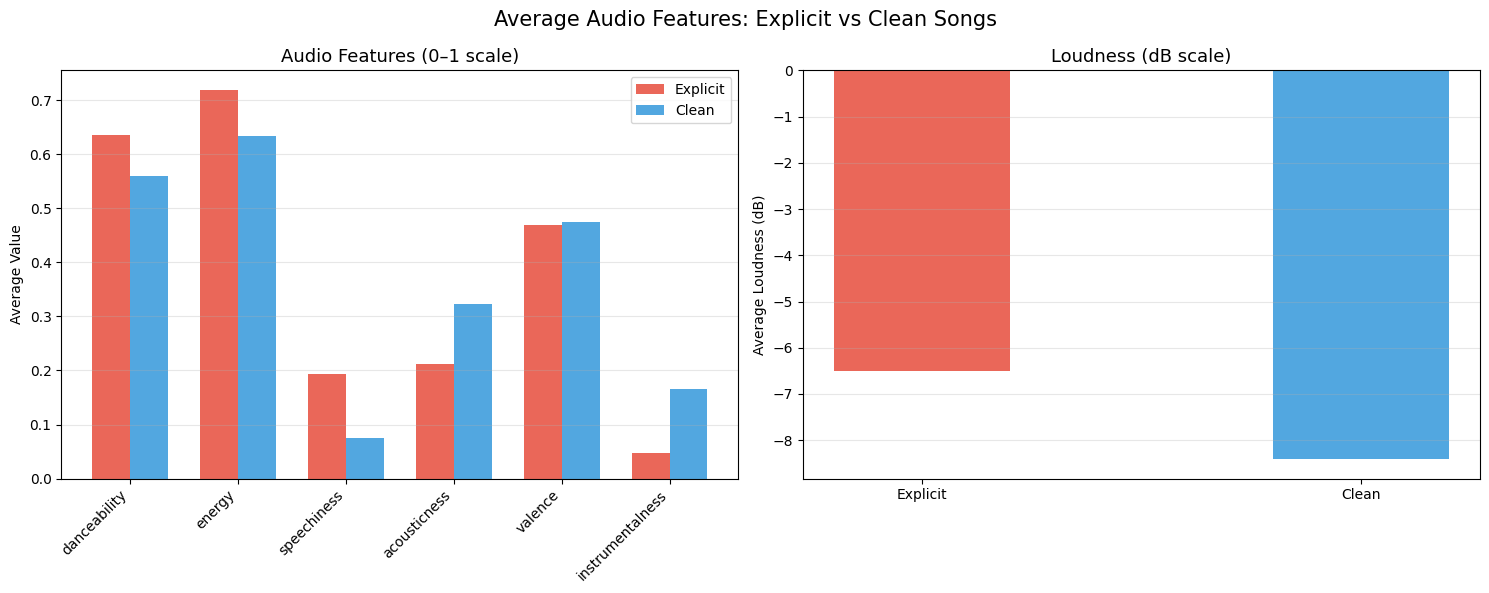

Figure saved!


In [9]:
#Two separate bar charts: one for 0-1 features, one for loudness
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Chart 1 — features on 0 to 1 scale
features_01 = ['danceability', 'energy', 'speechiness',
               'acousticness', 'valence', 'instrumentalness']

x1 = np.arange(len(features_01))
width = 0.35

ax1.bar(x1 - width/2, comparison.loc[features_01, 'Explicit'], width,
        label='Explicit', color='#E74C3C', alpha=0.85)
ax1.bar(x1 + width/2, comparison.loc[features_01, 'Clean'], width,
        label='Clean', color='#3498DB', alpha=0.85)
ax1.set_title('Audio Features (0–1 scale)', fontsize=13)
ax1.set_xticks(x1)
ax1.set_xticklabels(features_01, rotation=45, ha='right')
ax1.set_ylabel('Average Value')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Chart 2 — loudness only
ax2.bar(['Explicit', 'Clean'],
        [comparison.loc['loudness', 'Explicit'], comparison.loc['loudness', 'Clean']],
        color=['#E74C3C', '#3498DB'], alpha=0.85, width=0.4)
ax2.set_title('Loudness (dB scale)', fontsize=13)
ax2.set_ylabel('Average Loudness (dB)')
ax2.grid(axis='y', alpha=0.3)

fig.suptitle('Average Audio Features: Explicit vs Clean Songs', fontsize=15)
fig.tight_layout()
fig.savefig("../figures/explicit_vs_clean_features.png", dpi=300)
plt.show()
print("Figure saved!")

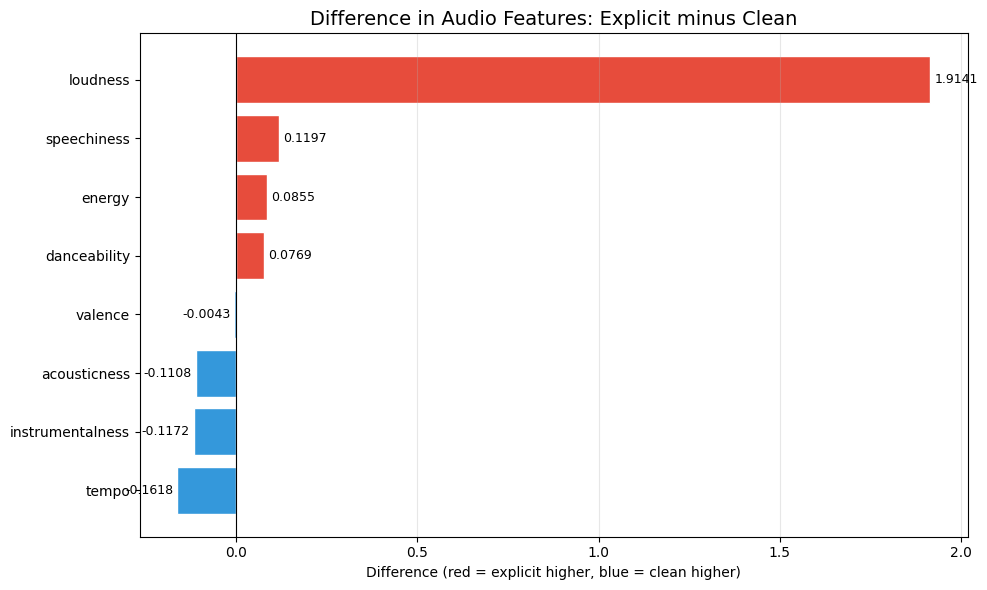

Figure saved!


In [10]:
# Difference bar chart: which features differ the most?
diff = comparison['Difference (Explicit - Clean)'].sort_values()
colors = ['#E74C3C' if v > 0 else '#3498DB' for v in diff]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(diff.index, diff.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
ax.set_title('Difference in Audio Features: Explicit minus Clean', fontsize=14)
ax.set_xlabel('Difference (red = explicit higher, blue = clean higher)')
ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/explicit_feature_difference.png", dpi=300)
plt.show()
print("Figure saved!")

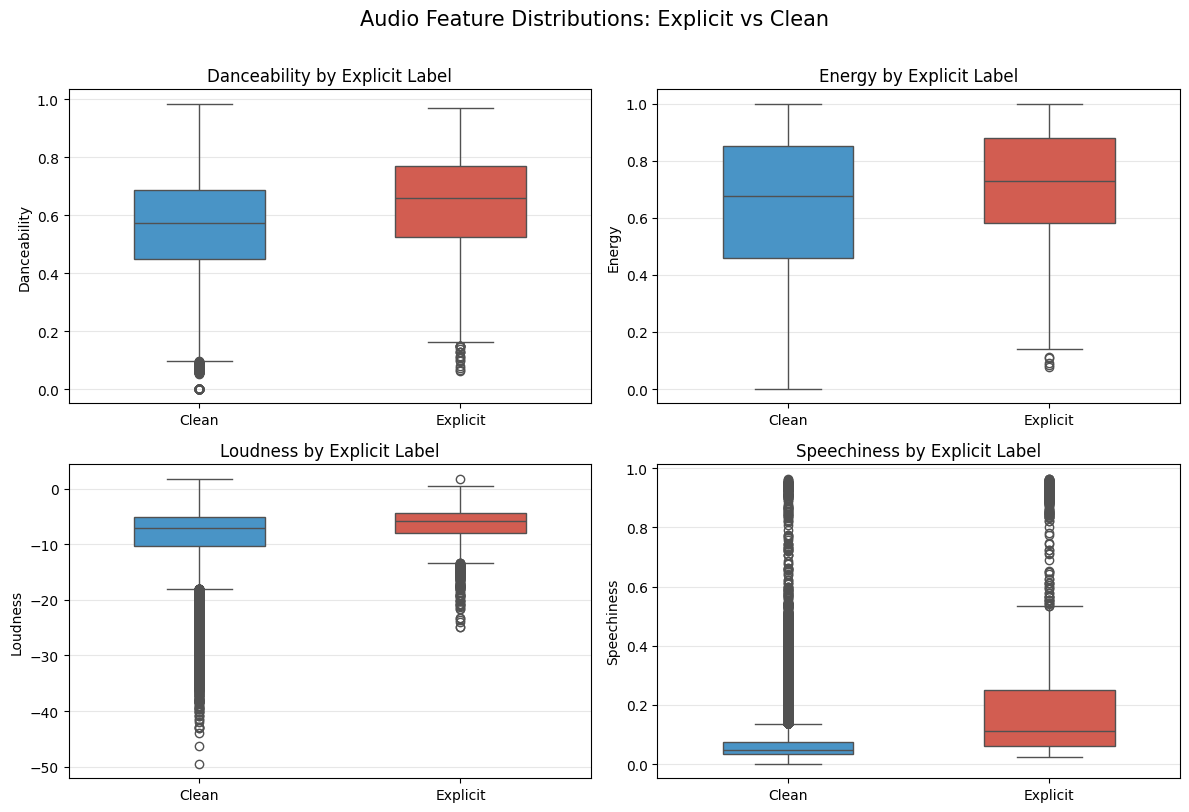

Figure saved!


In [12]:
#Box Plots — distribution of key features by explicit label
key_features = ['danceability', 'energy', 'loudness', 'speechiness']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

palette = {'Explicit': '#E74C3C', 'Clean': '#3498DB'}

for i, feat in enumerate(key_features):
    sns.boxplot(
    data=df, x='explicit_label', y=feat,
    hue='explicit_label', palette=palette, 
    ax=axes[i], width=0.5, legend=False
    )
    axes[i].set_title(f'{feat.capitalize()} by Explicit Label')
    axes[i].set_xlabel('')
    axes[i].set_ylabel(feat.capitalize())
    axes[i].grid(axis='y', alpha=0.3)

fig.suptitle('Audio Feature Distributions: Explicit vs Clean', fontsize=15, y=1.01)
fig.tight_layout()
fig.savefig("../figures/explicit_boxplots.png", dpi=300)
plt.show()
print("Figure saved!")

Top 15 genres by % of explicit songs:
track_genre  explicit_pct
     comedy          66.4
        emo          48.7
        sad          43.7
    j-dance          40.2
   hardcore          33.9
  dancehall          33.0
  metalcore          32.4
    hip-hop          29.5
       funk          28.8
death-metal          27.5
     latino          24.4
    turkish          23.2
  reggaeton          20.7
 industrial          20.7
     french          20.2


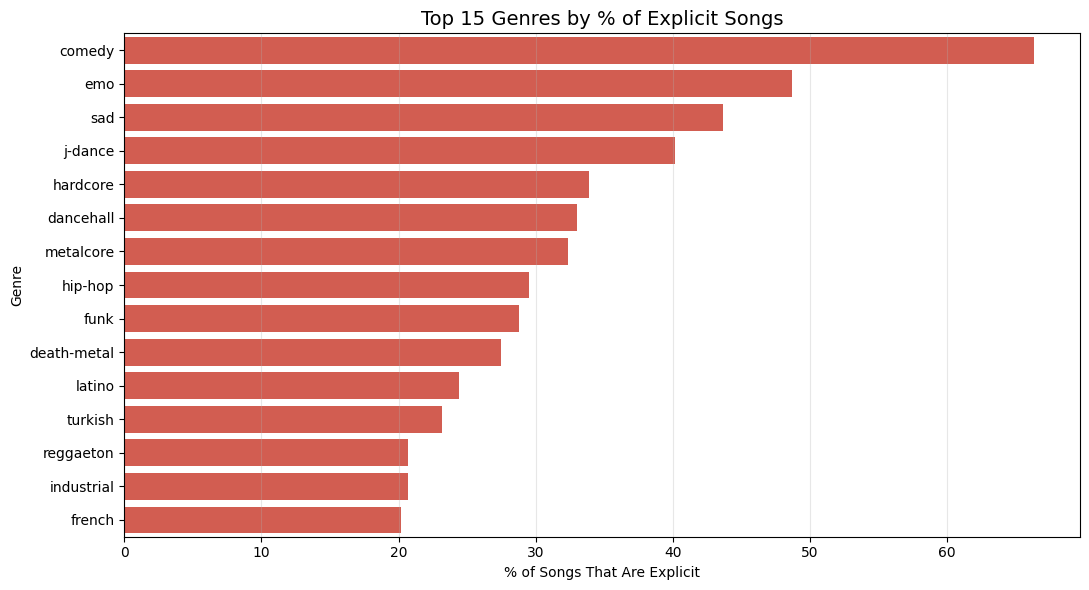

Figure saved!


In [14]:
# Which genres have the highest percentage of explicit songs?
genre_explicit = (
    df.groupby('track_genre')['explicit']
    .mean()
    .sort_values(ascending=False)
    .head(15)
    .reset_index()
)
genre_explicit.columns = ['track_genre', 'explicit_rate']
genre_explicit['explicit_pct'] = (genre_explicit['explicit_rate'] * 100).round(1)

print("Top 15 genres by % of explicit songs:")
print(genre_explicit[['track_genre', 'explicit_pct']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=genre_explicit, y='track_genre', x='explicit_pct',
            color='#E74C3C', ax=ax)
ax.set_title('Top 15 Genres by % of Explicit Songs', fontsize=14)
ax.set_xlabel('% of Songs That Are Explicit')
ax.set_ylabel('Genre')
ax.grid(axis='x', alpha=0.3)

fig.tight_layout()
fig.savefig("../figures/explicit_by_genre.png", dpi=300)
plt.show()
print("Figure saved!")

In [15]:
# Correlation of explicit with other features
df['explicit_num'] = df['explicit'].astype(int)

numeric_cols = features + ['popularity', 'explicit_num']
corr_matrix = df[numeric_cols].corr()

explicit_corr = corr_matrix['explicit_num'].drop('explicit_num').sort_values(key=abs, ascending=False)
print("Correlation of each feature with explicit (strongest first):")
print(explicit_corr.round(4))

Correlation of each feature with explicit (strongest first):
speechiness         0.3150
danceability        0.1229
loudness            0.1062
instrumentalness   -0.1057
energy              0.0945
acousticness       -0.0927
popularity          0.0457
valence            -0.0046
tempo              -0.0015
Name: explicit_num, dtype: float64


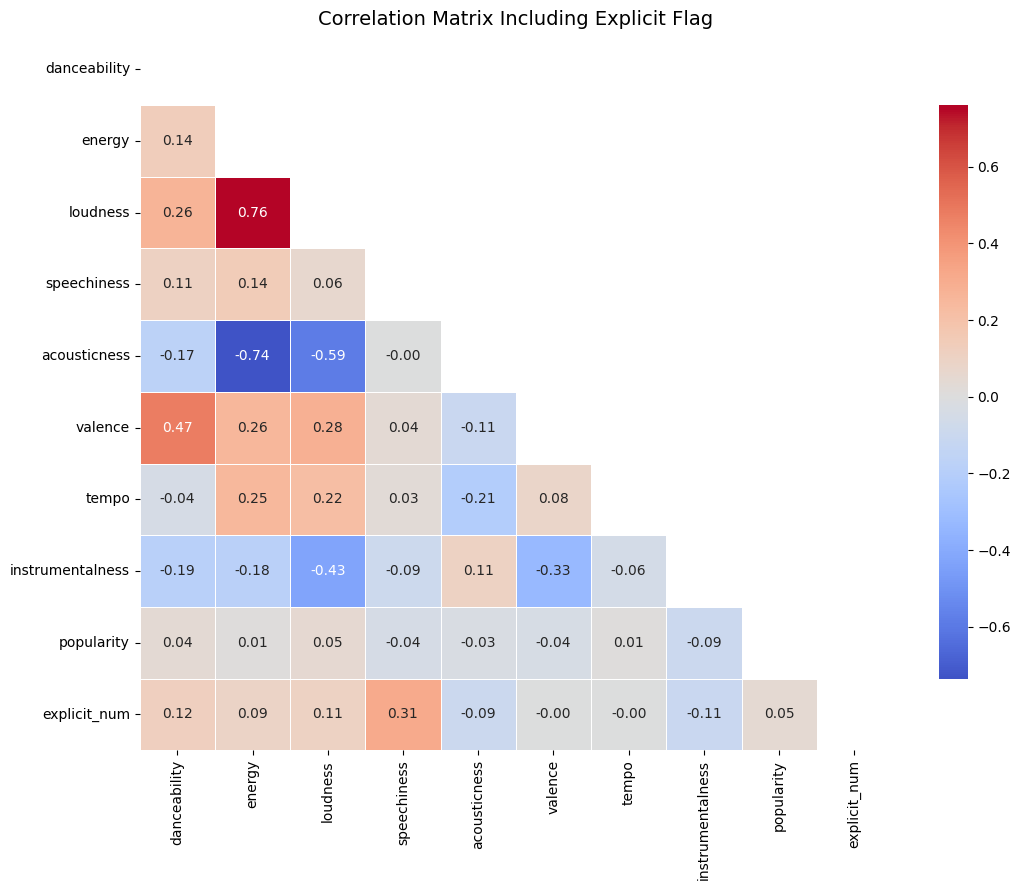

Figure saved!


In [16]:
# Correlation heatmap including explicit
fig, ax = plt.subplots(figsize=(11, 9))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlation Matrix Including Explicit Flag', fontsize=14)
fig.tight_layout()
fig.savefig("../figures/explicit_correlation_heatmap.png", dpi=300)
plt.show()
print("Figure saved!")

## Key Findings — Question 3: Do Explicit Songs Differ in Audio Features Compared to Non-Explicit Songs? (Rafik Taleb)

### Dataset Overview
- Clean songs: **45,778 (91.6%)**
- Explicit songs: **4,221 (8.4%)**
- Explicit songs make up **8.4%** of the dataset

### Audio Feature Differences
| Feature | Explicit | Clean | Difference |
|---------|----------|-------|------------|
| **loudness (dB)** | -6.49 | -8.41 | **+1.91** |
| **speechiness** | 0.194 | 0.074 | **+0.120** |
| **energy** | 0.720 | 0.634 | +0.086 |
| **danceability** | 0.636 | 0.560 | +0.077 |
| **instrumentalness** | 0.048 | 0.165 | -0.117 |
| **acousticness** | 0.212 | 0.323 | -0.111 |
| **valence** | 0.470 | 0.474 | -0.004 |

### Loudness is the Biggest Differentiator
- Explicit songs are **1.9 dB louder** on average
- This is the largest difference among all audio features
- Explicit tracks consistently show louder, more aggressive production

### Speechiness Shows the Most Distinct Pattern
- Explicit songs have **2.6× higher speechiness** (0.194 vs 0.074)
- Strongest correlation with explicit content: **r = 0.315**
- Makes sense — explicit content requires more lyrical density and spoken delivery

### Distribution Differences
- **Explicit songs** have wider distributions in energy and danceability
- **Clean songs** cluster more in mid-ranges with fewer extremes
- Box plots reveal explicit tracks have more high-energy outliers

### Explicit Content by Genre
- **Comedy (66.4%)** has highest percentage of explicit songs
- **Emo (48.7%)** and **Sad (43.7%)** follow — emotional genres often use explicit language
- **Hip-hop (29.5%)** is lower than expected — less than 1/3 of hip-hop tracks are explicit
- **Hardcore (33.9%)** and **Metalcore (32.4%)** show explicit content common in heavy genres

### Correlation Summary
- **Speechiness** (r = 0.315) — strongest positive correlation
- **Instrumentalness** (r = -0.106) — strongest negative correlation
- **Valence** (r = -0.005) — almost no relationship with mood
- **Popularity** (r = 0.046) — explicit doesn't significantly affect popularity

### Conclusion
Explicit songs are **louder, more energetic, and contain significantly more speech content** than clean songs. The biggest difference is in **loudness** (+1.9 dB), while **speechiness** is the strongest predictor of explicit content. Clean songs lean toward **acoustic and instrumental qualities**. Interestingly, **explicit content does not impact popularity** — listeners don't prefer or avoid songs based on explicit labels alone. The takeaway: **explicit songs bring more energy and speech, but not necessarily more streams.**